# Model Training Examples
## Contents
This notebook contains examples using the code created to train and test the hybrid model and Barlow Twins model.

There are a few configurable items for training, based on the experimental data. Regardless, the current approach for generating a classifier is as follows:
+ **Classes**:  5, labeled 0-4, with 0 being "new" and 4 being "broken"
+ **Epochs**:   Configurable until convergence, no code currently to stop prematurely, but if the process is interrupted the most recent model or model with the least loss is saved.
+ **Batch size**:   Configurable within each training module, though this may introduce more challenges on local machines.
+ **Analysis**: Suite for AUC - ROC curves as well as trends for classification versus scan index.

## Hybrid Model
Below is a notebook that can be configured to train the Hybrid model that uses a pre-trained CNN with ImageNetV1 weights. Using hardware acceleration, training may take up to an hour, depending on the number of epochs chosen.

The dataset is chosen from the files configured, with an 80/20 split between testing and validation.

Augmentation is done as to create 72 samples from a single image.

The training will report every 100 batches, and report epoch and total statistics for accuracy during training.

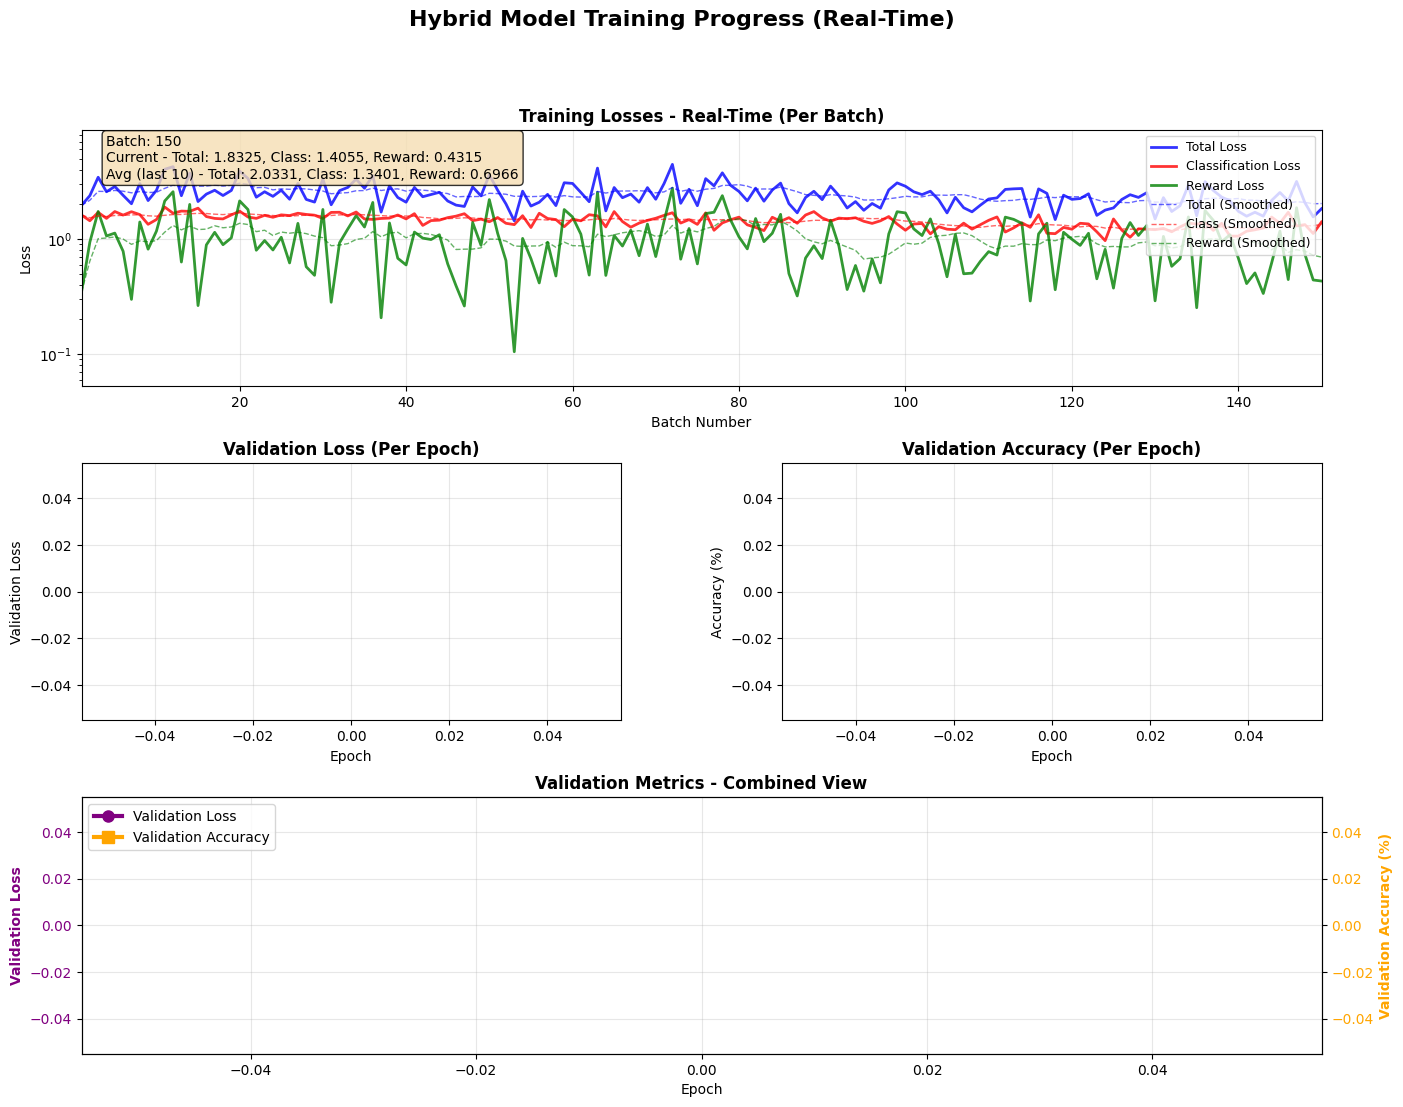

In [ ]:
# Main imports from tools.py and torch libraries. These are required to run the training
# and for evaluation. If you would like to reconfigure these files, find them in tools.py

from tools import (AugmentedIBWDataset, RewardAwareModel, train_hybrid_model, evaluate_hybrid_model,
    load_multi_dataset, custom_collate, train_hybrid_model_with_plotting)
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim       
import numpy as np

# Define the main function here. You can configure some items such as the hardware acceleration
# and other parameters for training, but to modify core features such as training weights
# and the backbone NN, consult tools.py.

def hybrid_model(base_folders, dataset_names, weights, batch_size, num_epochs):
    # Define the hardware acceleration tool here
    # CUDA -> MPS (Apple Silicon) -> CPU (UNIV.)
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') 
                            and torch.has_mps and torch.mps.is_available() else 'cpu')
    print(f"Using device: {device}")        # debug
    
    # This calls to loading the dataset from the .ibw files, assuming that the user
    # has configured the .ibw files in the same manner as discussed in README.md
    all_files, all_labels, all_scan_indices, dataset_info = load_multi_dataset(
        base_folders, dataset_names
    )
    
    # Summarizes the dataset, as well as the information about label distribution.
    # If this appears wrong, consider looking into tools.py
    print(f"\nDataset Summary:")
    print(f"Total files: {len(all_files)}")
    print(f"Label distribution: {np.bincount(all_labels)}")

    # Create augmented dataset, this is discussed in README.md
    print("\nCreating augmented dataset...")
    dataset = AugmentedIBWDataset(
        all_files, 
        all_labels, 
        all_scan_indices,
        compute_rewards=True,
        use_augmentation=True,
        augmentation_factor=72,  # 9 crops * 4 rotations * 2 flips = 72
        reward_weights=weights
    )
    
    print(f"Augmented dataset size: {len(dataset)} samples")
    print(f"Augmentation ratio: {len(dataset) / len(all_files):.1f}x")
    
    # Split dataset for training and validation, using an 80/20 train/test split
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    # Create dataloaders with smaller batch size due to increased data
    # You can configure these to create larger training and testing batches,
    # at the cost of time, 16 is a good spot between performance and accuracy
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                                 collate_fn=custom_collate, num_workers=0)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                               collate_fn=custom_collate, num_workers=0)
    
    print(f"Training batches: {len(train_dataloader)}")
    print(f"Validation batches: {len(val_dataloader)}")

    # Create model, referenced to the RewardAware Hybrid model
    model = RewardAwareModel(num_classes=5, pretrained=True)
    model = model.to(device)

    # Optimizer with adjusted learning rate for larger dataset
    # You may configure the parameters for the Adam optimizer as needed
    optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)

    print("\nStarting training...")

    # Configurable items:
    # num_epochs: the number of epochs (this model appears to perform well between 5-10)
    # use_adaptive_loss: whether to use adaptive loss for the training mode
    # train_losses, val_losses = train_hybrid_model(
    #     model,                                  # Model will be handled via torch library
    #     train_dataloader, 
    #     val_dataloader,                          
    #     optimizer,                              # Adam optimizer, can be changed
    #     device,                                 # Automatically configured from local machine
    #     num_epochs=num_epochs,                  # Number of epochs for training
    #     use_adaptive_loss=True                  # If you do not want to change training
    #                                             # weights during training (not recommended),
    #                                             # set to False
    # )

    # Train with live plotting, same configuration as above. This is a more "user friendly"
    # training function which shows the loss by batches and also updates the validation scores
    # per epoch. Note that this training function typically takes a while to complete.
    train_losses, val_losses, val_accuracies, plotter = train_hybrid_model_with_plotting(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        use_adaptive_loss=True,
        use_jupyter=True                          # Set to False if not using Jupyter
    )

    print("\nEvaluating on validation set...")

    # Calculates the accuracy of the model after training
    evaluate_hybrid_model(model, val_dataloader, device)
    
    # Save the trained model locally. You can configure this as needed, but note
    # that the model saves the state_dict and the optimizer dict as well
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, 'hybrid_model.pth')
    
    print("Model saved as 'hybrid_model.pth'.")


if __name__ == "__main__":
    # Load multiple datasets (setup for this repo)
    # Define the local folders (either relative or direct) that you can access these paths
    # from. You can also define subfolder names as needed, such as if you ran the same experiment
    # done here.
    # The following names will be left as placeholders:
    base_folders = ["exp_data/June 18"]
    dataset_names = ["read_out", "wear_out"]

    # Define the reward weights here for the augmented dataset and training
    weights = {
        'height_consistency': 0.25,
        'phase_consistency': 0.20, 
        'sharpness': 0.05,
        'snr': 0.25,
        'data_diversity': 0.01,
        'tip_freshness': 0.02,
        'scan_rate': 0.02
    }

    # Batch size chosen as 16 for performance
    batch_size = 16

    # Choose the number of epochs for training
    num_epochs = 10

    # NOTE: DROPOUT RATE FOR REWARDAWAREMODEL WAS 0.3, NOW 0.2

    hybrid_model(base_folders, dataset_names, weights, batch_size, num_epochs)  # Runs the above script, as this can be transferred to another .py file

    print(weights)


## Validating the Hybrid Model
Currently, the tools that can be used to validate the model accuracy use predictions based on the augmentation of images. **That is, a single `.ibw` file can be fed into the model and the average prediction out of all 72 augmented images will be used to classify the status of the tip based on training.** This is done to allow for adaptation of validation for real-time processing by using samples (such as a 86x86 image, of which up to 8 augmented images can be averaged to receive a prediction). **Since the model was trained on these augmented images, there is little concern for the lack of available data from such small images.**

The code below will solely take `.ibw` files that have been modeled similar to this experiment, i.e. they **require trace and retrace data as well as an index**. It is possible to consider an image without an index, but the proposed reward generation given to the prediction algorithm will not be as successful.

## Scan Index Versus Prediction (with Confidence Levels)

/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_97128/1826289476.py:11: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps')
/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_97128/1826289476.py:12: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  and torch.has_mps and torch.mps.is_available() else 'cpu')
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior 

Model loaded from hybrid_model.pth
Predicting quality for 36 files...
Processing file 1/36: exp_data/June 18/read_out/Read_out_0000.ibw
File: Read_out_0000.ibw, Extracted scan_index: 0
Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 0.989 confidence
Processing file 2/36: exp_data/June 18/read_out/Read_out_0001.ibw
File: Read_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 0.995 confidence
Processing file 3/36: exp_data/June 18/read_out/Read_out_0002.ibw
File: Read_out_0002.ibw, Extracted scan_index: 2
Scan Index: 2 Predicted: Class 0 (Excellent (Class 0)) with 0.998 confidence
Processing file 4/36: exp_data/June 18/read_out/Read_out_0003.ibw
File: Read_out_0003.ibw, Extracted scan_index: 3
Scan Index: 3 Predicted: Class 0 (Excellent (Class 0)) with 0.995 confidence
Processing file 5/36: exp_data/June 18/read_out/Read_out_0004.ibw
File: Read_out_0004.ibw, Extracted scan_index: 4
Scan Index: 4 Predicted: Class 0 (Excellent (Cl

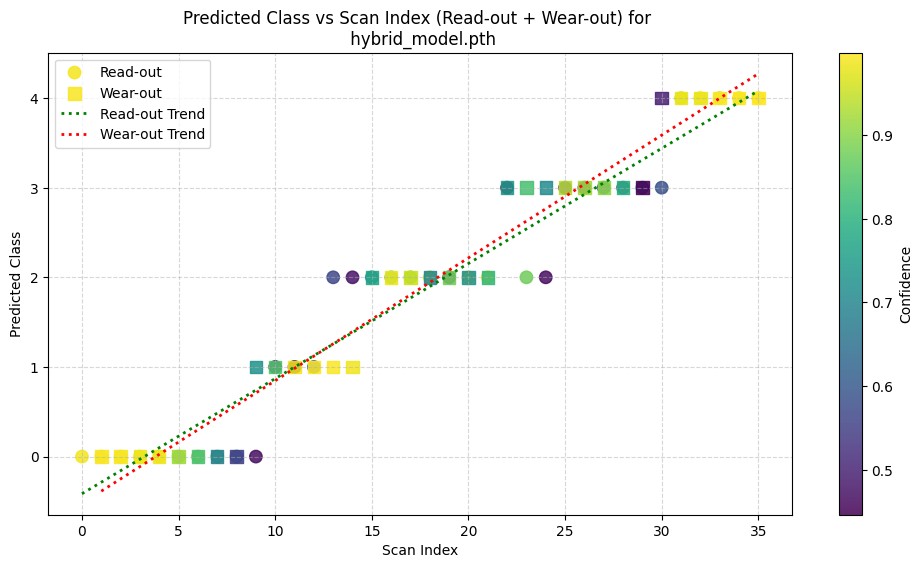

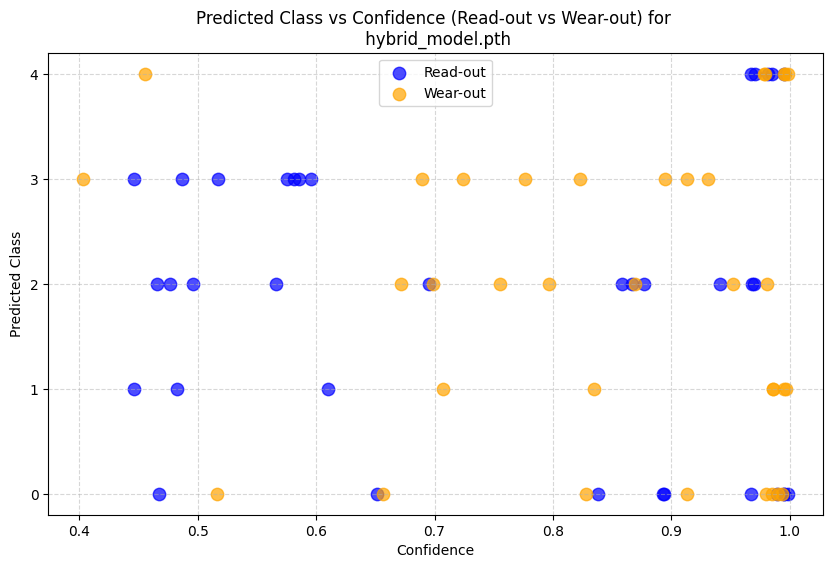

In [5]:
def plot_prediction_versus_index(model_path, base_folder, dataset_names):
    import os
    import numpy as np

    from tools import hb_predict_with_metadata          # Needed for prediction based on augments
    from tools import load_trained_hybrid_model         # For loading a saved model

    import torch

    # This defines the device that we can use for hardware acceleration, as done above
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') 
                                and torch.has_mps and torch.mps.is_available() else 'cpu')

    # This loads the trained model from the specified path
    model = load_trained_hybrid_model(model_path, device=device) # Change as needed to observe

    # Define the read_out_folder for prediction with the metadata from training and .ibw files
    read_out_folder = os.path.join(base_folder, dataset_names[0])
    read_out_files = sorted([
        os.path.join(read_out_folder, f)
        for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])

    # The same process applies to wear_out folders
    wear_out_folder = os.path.join(base_folder, dataset_names[1])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f)
        for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])

    # If you have metadata, instead we use defaults from the experiment
    model_metadata_path = ""

    # Grabs the results from each file, averaged over the 72 augmented images
    results_read = hb_predict_with_metadata(model, read_out_files, model_metadata_path, device)
    results_wear = hb_predict_with_metadata(model, wear_out_files, model_metadata_path, device)

    # Read-out
    scan_indices_read = [r.get('scan_index', r.get('scan_index_used', i + 1)) for i, r in enumerate(results_read)]
    predicted_classes_read = [r['predicted_class'] for r in results_read]
    confidences_read = [r['confidence'] for r in results_read]

    # Wear-out (reset scan index to start from 1)
    scan_indices_wear = [i + 1 for i in range(len(results_wear))]
    predicted_classes_wear = [r['predicted_class'] for r in results_wear]
    confidences_wear = [r['confidence'] for r in results_wear]


    # --- PLOTTING ---
    import matplotlib.pyplot as plt

    # Plot both with confidence as color, wear-out as squares, read-out as circles
    plt.figure(figsize=(12, 6))

    # Read-out: circles, color by confidence
    scatter1 = plt.scatter(
        scan_indices_read, predicted_classes_read, 
        c=confidences_read, cmap='viridis', s=80, alpha=0.85, label='Read-out', marker='o'
    )
    # Wear-out: squares, color by confidence
    scatter2 = plt.scatter(
        scan_indices_wear, predicted_classes_wear, 
        c=confidences_wear, cmap='viridis', s=80, alpha=0.85, label='Wear-out', marker='s'
    )

    # Add trendline for read-out
    z_read = np.polyfit(scan_indices_read, predicted_classes_read, 1)
    p_read = np.poly1d(z_read)
    plt.plot(scan_indices_read, p_read(scan_indices_read), color='green', linewidth=2, linestyle=':', label='Read-out Trend')

    # Add trendline for wear-out
    z_wear = np.polyfit(scan_indices_wear, predicted_classes_wear, 1)
    p_wear = np.poly1d(z_wear)
    plt.plot(scan_indices_wear, p_wear(scan_indices_wear), color='red', linewidth=2, linestyle=':', label='Wear-out Trend')

    # General plot configuration--may require labeling changers
    plt.xlabel('Scan Index')
    plt.ylabel('Predicted Class')
    plt.title(f'Predicted Class vs Scan Index (Read-out + Wear-out) for \n {model_path}')
    plt.yticks(range(5), ['0', '1', '2', '3', '4'])
    cbar = plt.colorbar(scatter1, label='Confidence', orientation='vertical')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.scatter(confidences_read, predicted_classes_read, c='blue', label='Read-out', alpha=0.7, s=80)
    plt.scatter(confidences_wear, predicted_classes_wear, c='orange', label='Wear-out', alpha=0.7, s=80)
    plt.xlabel('Confidence')
    plt.ylabel('Predicted Class')
    plt.title(f'Predicted Class vs Confidence (Read-out vs Wear-out) for \n {model_path}')
    plt.yticks(range(5), ['0', '1', '2', '3', '4'])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


if __name__ == "__main__":
    # Define the model path here
    model_path = 'hybrid_model.pth'

    # Define the base folder and the subfolders which contain the set of data
    # This *is* configurable for other experiments, but will not be labeled as such
    # Change the above functions for plotting if the experimental procedure changes
    base_folder = "exp_data/June 18"
    dataset_names = ["read_out", "wear_out"]

    # Usage
    plot_prediction_versus_index(model_path, base_folder, dataset_names)


## ROC - AUC Curve

/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_97128/1830016371.py:9: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from hybrid_model.pth
Predicting quality for 36 files...
Processing file 1/36: exp_data/June 18/read_out/Read_out_0000.ibw
File: Read_out_0000.ibw, Extracted scan_index: 0
Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 0.989 confidence
Processing file 2/36: exp_data/June 18/read_out/Read_out_0001.ibw
File: Read_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 0.995 confidence
Processing file 3/36: exp_data/June 18/read_out/Read_out_0002.ibw
File: Read_out_0002.ibw, Extracted scan_index: 2
Scan Index: 2 Predicted: Class 0 (Excellent (Class 0)) with 0.998 confidence
Processing file 4/36: exp_data/June 18/read_out/Read_out_0003.ibw
File: Read_out_0003.ibw, Extracted scan_index: 3
Scan Index: 3 Predicted: Class 0 (Excellent (Class 0)) with 0.995 confidence
Processing file 5/36: exp_data/June 18/read_out/Read_out_0004.ibw
File: Read_out_0004.ibw, Extracted scan_index: 4
Scan Index: 4 Predicted: Class 0 (Excellent (Cl

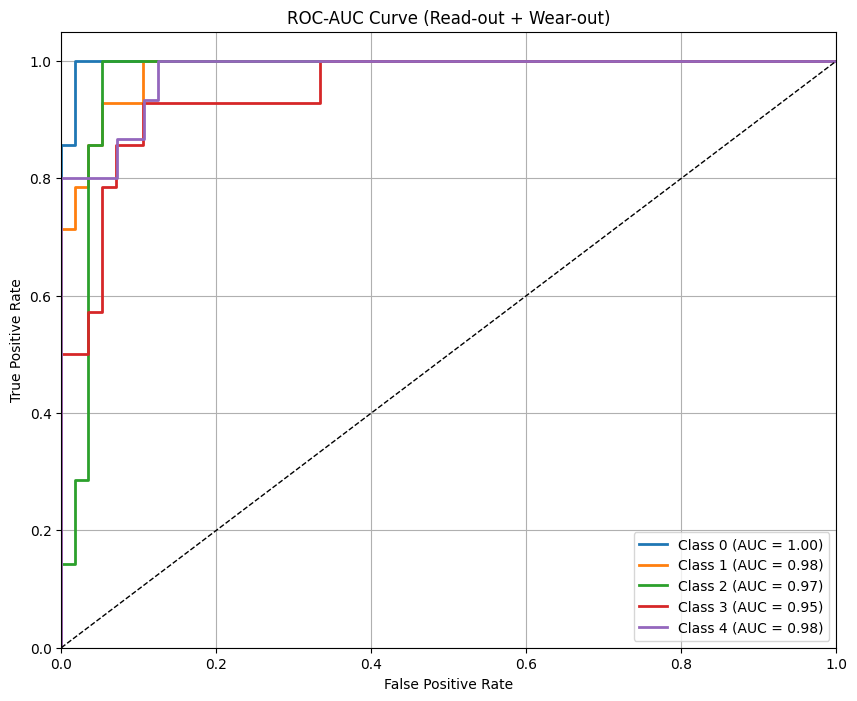


Per-Class AUC Scores:
  Class 0: 0.9975
  Class 1: 0.9850
  Class 2: 0.9699
  Class 3: 0.9499
  Class 4: 0.9798
Model loaded from hybrid_model.pth
Found 36 files in exp_data/June 18/read_out
Found 35 files in exp_data/June 18/wear_out
Predicting quality for 71 files...
Processing file 1/71: exp_data/June 18/read_out/Read_out_0000.ibw
File: Read_out_0000.ibw, Extracted scan_index: 0


/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_97128/1830016371.py:72: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/Users/colin/Documents/GitHub/ofdspm/tools.py:2106: UserWarning: 'has_mps' is deprecated, please use 'to

Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 0.989 confidence
Processing file 2/71: exp_data/June 18/wear_out/Wear_out_0000.ibw
File: Wear_out_0000.ibw, Extracted scan_index: 0
Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 0.993 confidence
Processing file 3/71: exp_data/June 18/read_out/Read_out_0001.ibw
File: Read_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 0.995 confidence
Processing file 4/71: exp_data/June 18/wear_out/Wear_out_0001.ibw
File: Wear_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 0.990 confidence
Processing file 5/71: exp_data/June 18/read_out/Read_out_0002.ibw
File: Read_out_0002.ibw, Extracted scan_index: 2
Scan Index: 2 Predicted: Class 0 (Excellent (Class 0)) with 0.998 confidence
Processing file 6/71: exp_data/June 18/wear_out/Wear_out_0002.ibw
File: Wear_out_0002.ibw, Extracted scan_index: 2
Scan Index: 2 Predicted: Class 0 (Excell

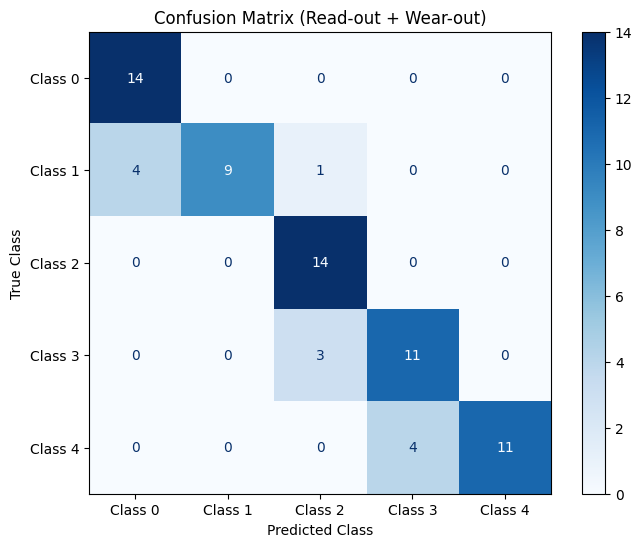

In [6]:
def hb_roc_auc_script(model_path, base_folder, dataset_names):
    import torch.nn.functional as F
    import torch
    from tools import load_trained_hybrid_model, add_true_labels_to_results_using_scan_indices
    from tools import hb_generate_roc_auc_curve
    import os

    metadata_path = "model_training_metadata.pkl"   # Don't need to change
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')

    # Loads the mode
    model = load_trained_hybrid_model(model_path, device=device)

    # Define the read_out_folder for prediction with the metadata from training and .ibw files
    read_out_folder = os.path.join(base_folder, dataset_names[0])
    read_out_files = sorted([
        os.path.join(read_out_folder, f)
        for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])

    # The same process applies to wear_out folders
    wear_out_folder = os.path.join(base_folder, dataset_names[1])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f)
        for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])

    read_out_files = sorted([
        os.path.join(read_out_folder, f) for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f) for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])

    from tools import hb_predict_with_metadata

    # # Predict on both datasets
    results_read = hb_predict_with_metadata(model, read_out_files, metadata_path, device)
    results_wear = hb_predict_with_metadata(model, wear_out_files, metadata_path, device)

    # Combine results and generate ROC curve
    all_results = results_read + results_wear
    all_results = add_true_labels_to_results_using_scan_indices(all_results)

    # inspect_results(all_results)
    roc_auc = hb_generate_roc_auc_curve(all_results, num_classes=5, title="ROC-AUC Curve (Read-out + Wear-out)")

    print("\nPer-Class AUC Scores:")
    for cls, score in roc_auc.items():
        print(f"  Class {cls}: {score:.4f}")


if __name__ == "__main__":
    # Configure the file base folder here for predictions
    base_folder = "exp_data/June 18"
    dataset_names = ["read_out", "wear_out"]
    model_path = 'hybrid_model.pth'

    # Run the script (useful in other .py files)
    hb_roc_auc_script(model_path, base_folder, dataset_names)


    # Run the confusion matrix script as well
    from tools import hb_compute_confusion_matrix_from_multiple_folders
    from tools import load_trained_hybrid_model
    import torch

    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
    model = load_trained_hybrid_model(model_path, device=device)


    hb_compute_confusion_matrix_from_multiple_folders(
        parent_folder=base_folder,
        subfolders=dataset_names,
        model=model,
        num_classes=5,
        title="Confusion Matrix (Read-out + Wear-out)"
    )


## Barlow Twins Model


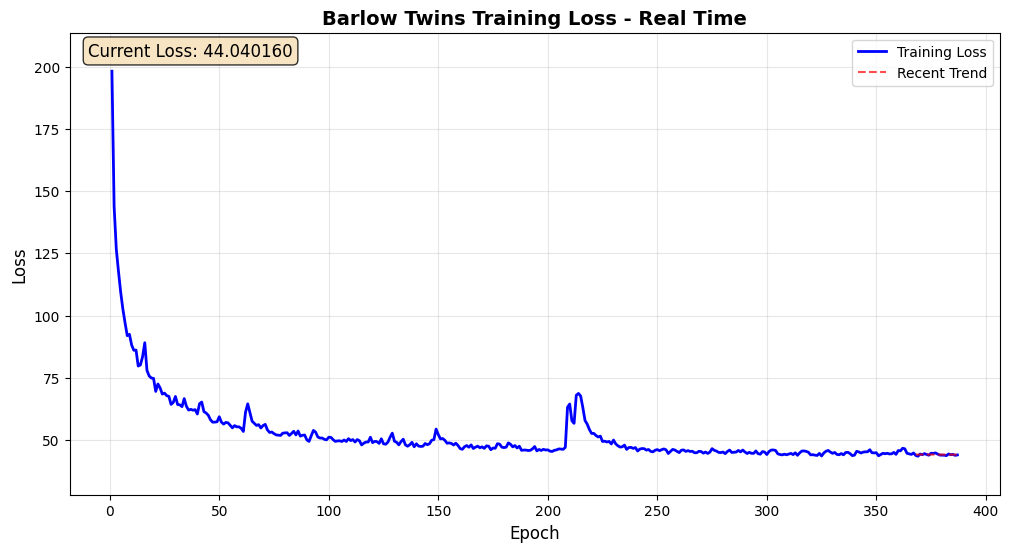

Epoch [387/1000] completed. Average Loss: 44.040160
------------------------------
Epoch [388/1000], Batch [1/20], Loss: 43.255623
Epoch [388/1000], Batch [11/20], Loss: 43.817348

Training interrupted by user
Saved encoder to barlow_twins_encoder.pth


In [1]:
def main(base_folder, dataset_names, num_epochs):
    import torch
    import torch.optim as optim
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    import torchvision.transforms as transforms
    import torchvision.models as models
    import os
    from tools import BT_AFMBarlowDataset, BarlowTwinsLoss
    from tools import load_ibw
    from tools import train_barlow_twins_with_plotting, is_jupyter
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load IBW data
    ibw_data_list = []
    for folder in dataset_names:
        folder_path = os.path.join(base_folder, folder)
        for file in sorted(os.listdir(folder_path)):
            if file.lower().endswith(".ibw"):
                ibw_path = os.path.join(folder_path, file)
                try:
                    ibw = load_ibw(ibw_path)
                    ibw_data_list.append(ibw.z)  # assumes .z is 256x256
                except Exception as e:
                    print(f"Failed to load {ibw_path}: {e}")
    
    print(f"Loaded {len(ibw_data_list)} IBW height images")
    
    # Define transforms for self-supervised learning
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])
    
    # Create dataset and dataloader
    dataset = BT_AFMBarlowDataset(ibw_data_list, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)
    
    # Base encoder (ResNet18), note this is NOT pretrained
    encoder = models.resnet18(pretrained=False)
    encoder.fc = nn.Identity()
    model = nn.Sequential(encoder).to(device)
    
    # Setup training components
    loss_fn = BarlowTwinsLoss()
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    
    # Detect environment and train with real-time plotting
    jupyter_mode = is_jupyter()
    print(f"Detected environment: {'Jupyter Notebook' if jupyter_mode else 'Regular Python'}")
    
    train_barlow_twins_with_plotting(model, dataloader, loss_fn, optimizer, device, 
                                   epochs=num_epochs, use_jupyter=jupyter_mode)
    
    # Save model
    torch.save(model.state_dict(), "barlow_twins_encoder.pth")
    print("Saved encoder to barlow_twins_encoder.pth")

if __name__ == "__main__":
    num_epochs = 1000  # Define the number of epochs here
    
    # Configure folders and files
    base_folder = "exp_data/June 18"
    dataset_names = ["read_out", "wear_out"]
    
    # Run the script
    main(base_folder, dataset_names, num_epochs)

## Training the Classifier From the Barlow Twins Encoder

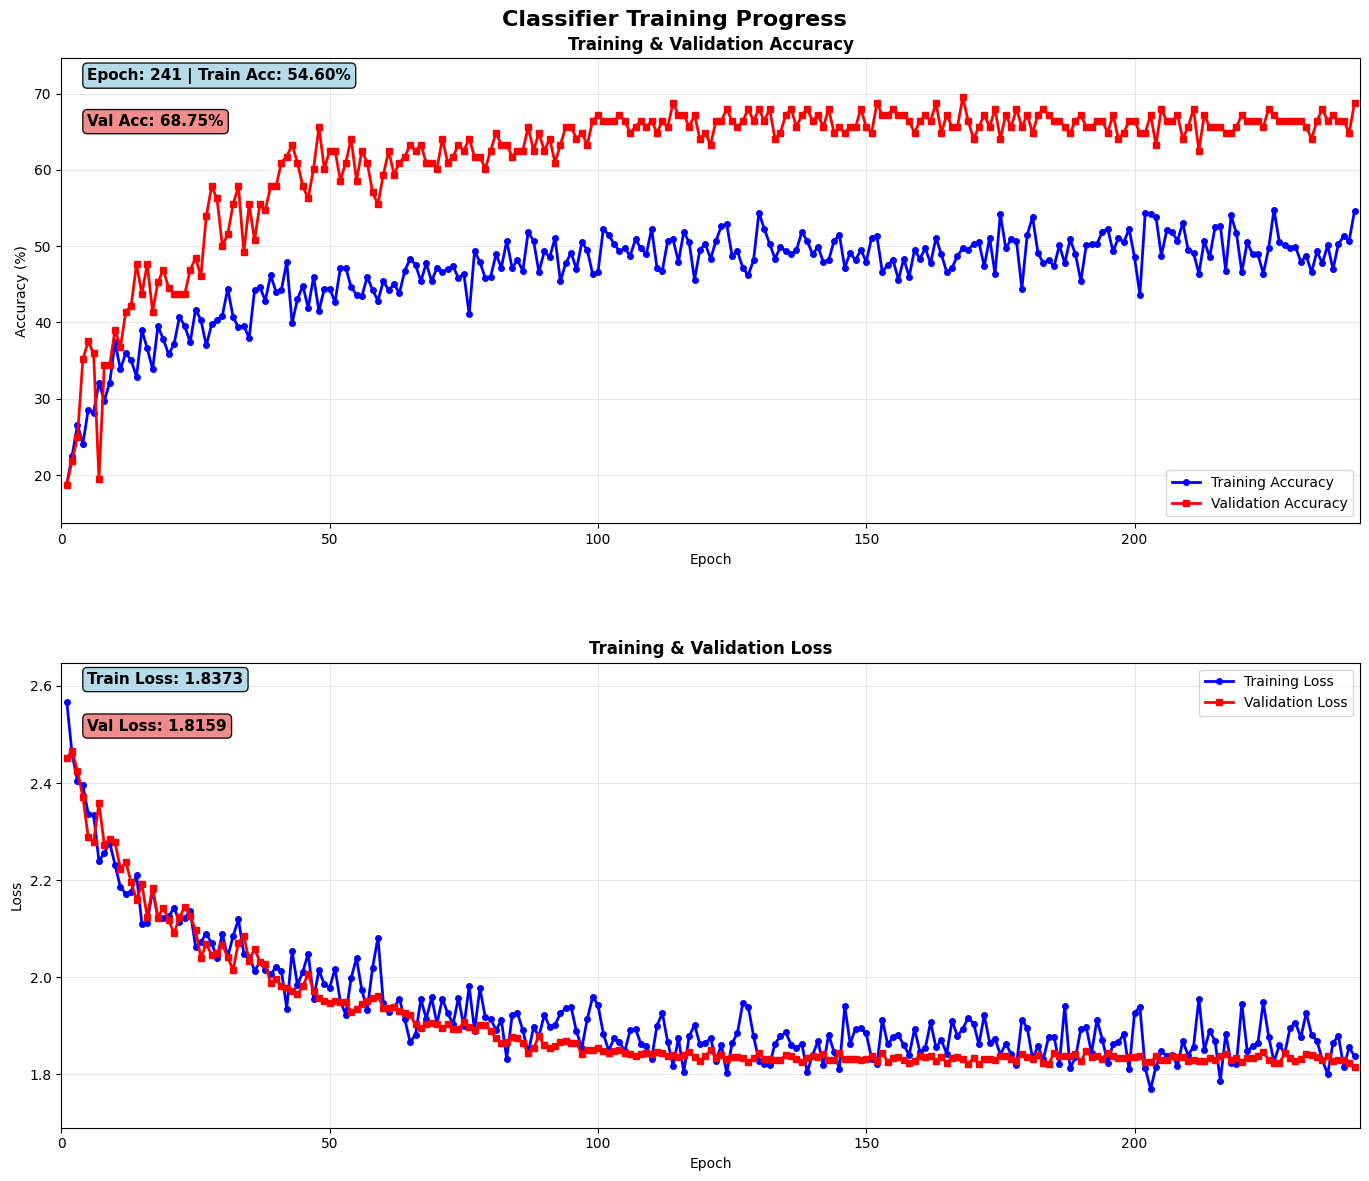

Epoch 241/400
  Train Loss: 1.8373 | Val Loss: 1.8159
  Train Acc: 54.60% | Val Acc: 68.75%
  Class Loss: 1.8373
  Reward Loss: 0.8566
  Saved best model (Val Loss: 1.8159, Val Acc: 68.75%)
------------------------------------------------------------

Training interrupted by user

Training Summary:
Best Validation Loss: 1.8159
Best Validation Accuracy: 68.75%

Final evaluation on validation set:
Final Validation Loss: 1.8147
Final Validation Accuracy: 68.75%

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.71      0.71      0.71        31
     Class 1       0.55      0.68      0.61        25
     Class 2       0.60      0.36      0.45        25
     Class 3       0.70      0.96      0.81        24
     Class 4       0.94      0.74      0.83        23

    accuracy                           0.69       128
   macro avg       0.70      0.69      0.68       128
weighted avg       0.70      0.69      0.68       128

Training comple

In [1]:
def main(encoder_path, base_folder, dataset_names, weights, num_epochs, reward_weight):
    import torch
    from torch.utils.data import Dataset, DataLoader, random_split
    import torchvision.transforms as transforms
    import torch.optim as optim
    import torch.nn as nn
    import torchvision.models as models
    import os

    from tools import load_ibw
    from tools import EnhancedBT_AFMDataset, BarlowTwinsClassifier
    from tools import bt_train_classifier, bt_evaluate_classifier
    from tools import bt_train_classifier_with_plotting
    from sklearn.metrics import classification_report

    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load IBW data
    ibw_data_list = []
    scan_indices = []
    
    print("Loading IBW files...")
    for folder in dataset_names:
        folder_path = os.path.join(base_folder, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(".ibw")])
        print(f"Found {len(files)} IBW files in {folder}")
        
        for i, file in enumerate(files):
            path = os.path.join(folder_path, file)
            try:
                ibw = load_ibw(path)
                ibw_data_list.append(ibw)
                # Extract scan index from filename or use sequential numbering
                scan_idx = i + 1  # You might want to parse this from filename
                scan_indices.append(scan_idx)
            except Exception as e:
                print(f"Error loading {path}: {e}")
    
    print(f"Successfully loaded {len(ibw_data_list)} IBW files")
    
    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Create dataset with multi-class labeling
    dataset = EnhancedBT_AFMDataset(
        ibw_data_list, 
        scan_indices, 
        compute_rewards=True,  # Compute rewards for potential use
        transform=transform,
        use_augmentation=True,
        crops_per_image=9,
        reward_weights=weights
    )
    
    print(f"Dataset size: {len(dataset)} samples")
    print(f"Augmentation factor: {len(dataset) / len(ibw_data_list):.1f}x")
    
    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Create model
    model = BarlowTwinsClassifier(
        encoder_path=encoder_path,
        num_classes=5,  
        include_reward_head=True,   # Include reward prediction
        freeze_encoder=True,        # Freeze encoder initially
        dropout_rate=0.3
    )
    model = model.to(device)
    
    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Optimizer - only optimize trainable parameters
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3, 
        weight_decay=1e-4
    )
    
    # # Train the classifier
    # print("\nStarting training...")
    # train_losses, val_losses = bt_train_classifier(
    #     model, train_loader, val_loader, optimizer, device,
    #     num_epochs=num_epochs,
    #     use_reward_loss=True,
    #     reward_weight=reward_weight
    # )
    
    train_losses, val_losses = bt_train_classifier_with_plotting(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        use_reward_loss=True, 
        reward_weight=reward_weight,
        use_jupyter=True
        )

    # Final evaluation
    print("\nFinal evaluation on validation set:")
    val_loss, val_accuracy = bt_evaluate_classifier(model, val_loader, device, 
                                                use_reward_loss=True, reward_weight=reward_weight)
    print(f"Final Validation Loss: {val_loss:.4f}")
    print(f"Final Validation Accuracy: {val_accuracy:.2f}%")
    
    # Detailed classification report
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_data in val_loader:
            if len(batch_data) >= 2:
                inputs, labels = batch_data[0], batch_data[1]
                inputs = inputs.to(device)
                
                if model.include_reward_head:
                    class_outputs, _ = model(inputs)
                else:
                    class_outputs = model(inputs)
                
                _, predicted = torch.max(class_outputs.data, 1)
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
    
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_predictions, 
                              target_names=[f'Class {i}' for i in range(5)]))
    
    # Save final model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_accuracy': val_accuracy,
    }, 'barlow_twins_multiclass_classifier.pth')
    
    print("Training completed! Model saved as 'barlow_twins_multiclass_classifier.pth'")

if __name__ == "__main__":
    # Data loading parameters
    base_folder = "exp_data/June 18"
    dataset_names = ["read_out", "wear_out"]
    encoder_path = 'best_barlow_twins_encoder.pth'

    weights = {
        'height_consistency': 0.25,
        'phase_consistency': 0.20, 
        'sharpness': 0.5,
        'snr': 0.25,
        'data_diversity': 0.01,
        'tip_freshness': 0.02,
        'scan_rate': 0.02
    }

    reward_weight = 0.75
    num_epochs = 400

    main(encoder_path, base_folder, dataset_names, weights, num_epochs, reward_weight)

## Validating the Barlow Twins Model

## Scan Index Versus Prediction (with Confidence Levels)

/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_97128/1970754666.py:13: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Processing exp_data/June 18/read_out/Read_out_0007.ibw...
File: exp_data/June 18/read_out/Read_out_0007.ibw, Predicted Class: []
Processing exp_data/June 18/read_out/Read_out_0013.ibw...
File: exp_data/June 18/read_out/Read_out_0013.ibw, Predicted Class: [{'file': 'exp_data/June 18/read_out/Read_out_0007.ibw', 'probabilities': array([0.27947852, 0.44761193, 0.12493658, 0.09095491, 0.05701807],
      dtype=float32), 'scan_index': 7, 'status': 'success'}]
Processing exp_data/June 18/read_out/Read_out_0012.ibw...
File: exp_data/June 18/read_out/Read_out_0012.ibw, Predicted Class: [{'file': 'exp_data/June 18/read_out/Read_out_0007.ibw', 'probabilities': array([0.27947852, 0.44761193, 0.12493658, 0.09095491, 0.05701807],
      dtype=float32), 'scan_index': 7, 'status': 'success'}, {'file': 'exp_data/June 18/read_out/Read_out_0013.ibw', 'probabilities': array([0.17244995, 0.36969674, 0.24706595, 0.14436401, 0.0664234 ],
      dtype=float32), 'scan_index': 13, 'status': 'success'}]
Processing

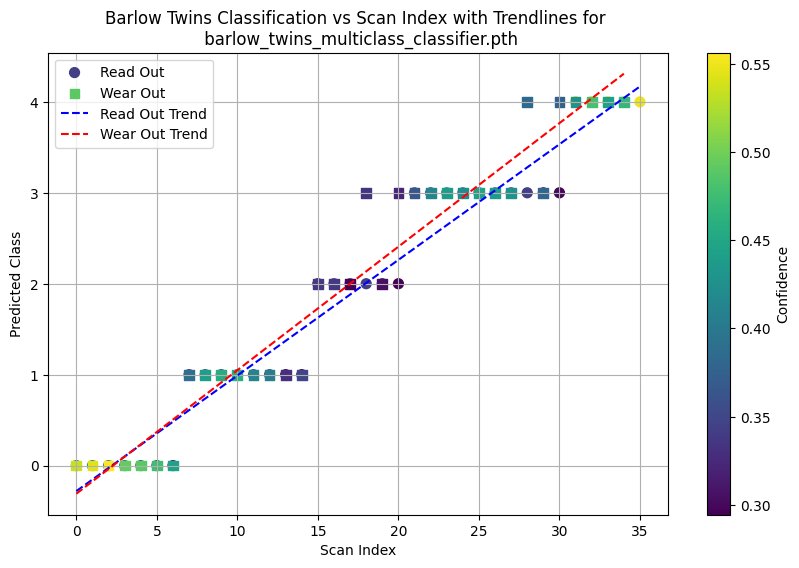

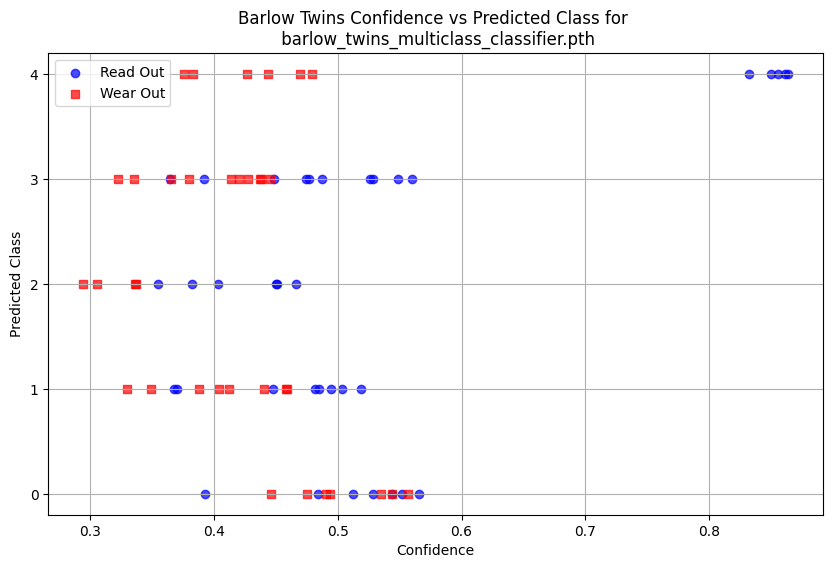

In [2]:
def main(model_path, base_folder, dataset_names):
    import os
    import torch
    import torchvision.transforms as transforms
    import torch.nn as nn
    import numpy as np


    # import the updated prediction function
    from tools import bt_load_multiclass_classifier, bt_predict_with_probabilities
    from tools import bt_plot_classification_vs_scan_index, bt_plot_confidence_vs_predicted_class

    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')

    model = bt_load_multiclass_classifier(model_path, device=device, num_classes=5)

    transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    ibw_file_paths = []
    for subfolder in dataset_names:
        folder_path = os.path.join(base_folder, subfolder)
        if os.path.exists(folder_path):
            ibw_file_paths += [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(".ibw")]

    results = []
    for file_path in ibw_file_paths:
        print(f"Processing {file_path}...")
        result = bt_predict_with_probabilities(model, transform, file_path, device=device)

        # Add some lines here so we can ensure that the prediction results are saved
        print(f"File: {file_path}, Predicted Class: {results}")
        results.append(result)

    # model_metadata_path = "model_training_metadata.pkl"
    # results = hb_predict_with_metadata(model, ibw_file_paths, model_metadata_path, device)

    # Add predicted_class and confidence for each result
    for r in results:
        if r["status"] == "success" and r["probabilities"] is not None:
            r["predicted_class"] = np.argmax(r["probabilities"])
            r["confidence"] = float(r["probabilities"][r["predicted_class"]])
        else:
            r["predicted_class"] = None
            r["confidence"] = None

    print(f"Total files processed: {len(results)}")

    bt_plot_classification_vs_scan_index(results, title=f"Barlow Twins Classification vs Scan Index with Trendlines for \n {model_path}")
    bt_plot_confidence_vs_predicted_class(results, title=f"Barlow Twins Confidence vs Predicted Class for \n {model_path}")

if __name__ == "__main__":
    model_path = "barlow_twins_multiclass_classifier.pth"
    base_folder = "exp_data/June 18"
    dataset_names = ['read_out', 'wear_out']

    main(model_path, base_folder, dataset_names)

## ROC - AUC Curve

/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_97128/4255262076.py:3: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps')
/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_97128/4255262076.py:4: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  and torch.has_mps and torch.mps.is_available() else 'cpu')
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is

=== STARTING ROC ANALYSIS ===
Using device: mps
Processing read_out folder...


Processing read_out: 100%|██████████| 36/36 [00:01<00:00, 24.99it/s]


Processing wear_out folder...


Processing wear_out: 100%|██████████| 35/35 [00:01<00:00, 23.64it/s]


Collected 71 predictions for ROC analysis
Overall Accuracy: 0.268
Generating ROC curves...


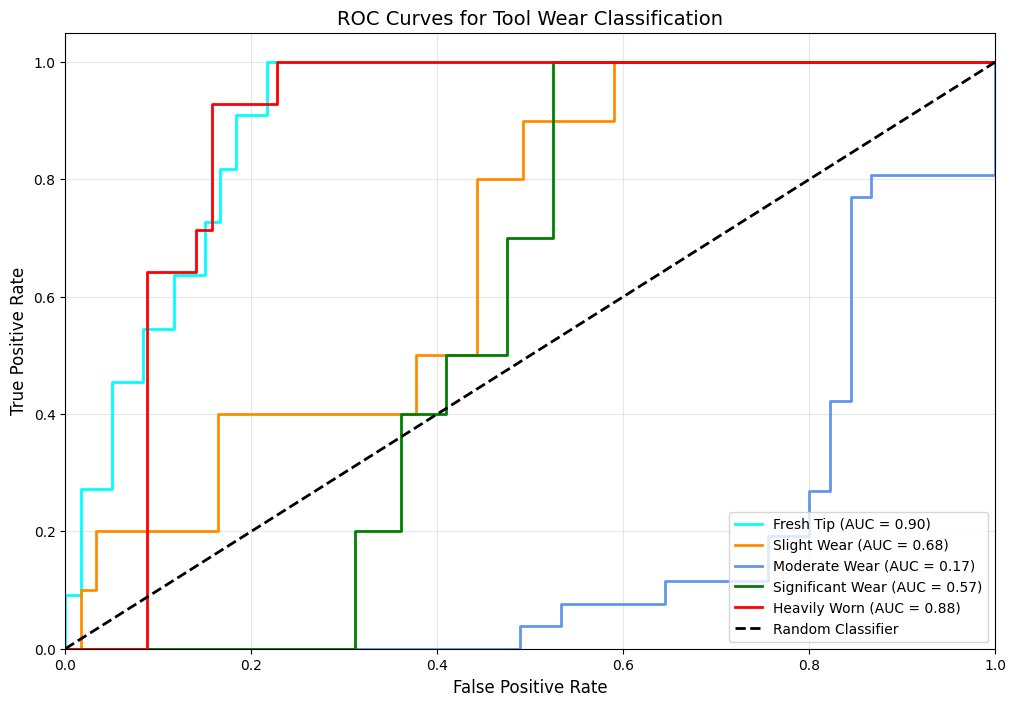

Generating individual class ROC curves...


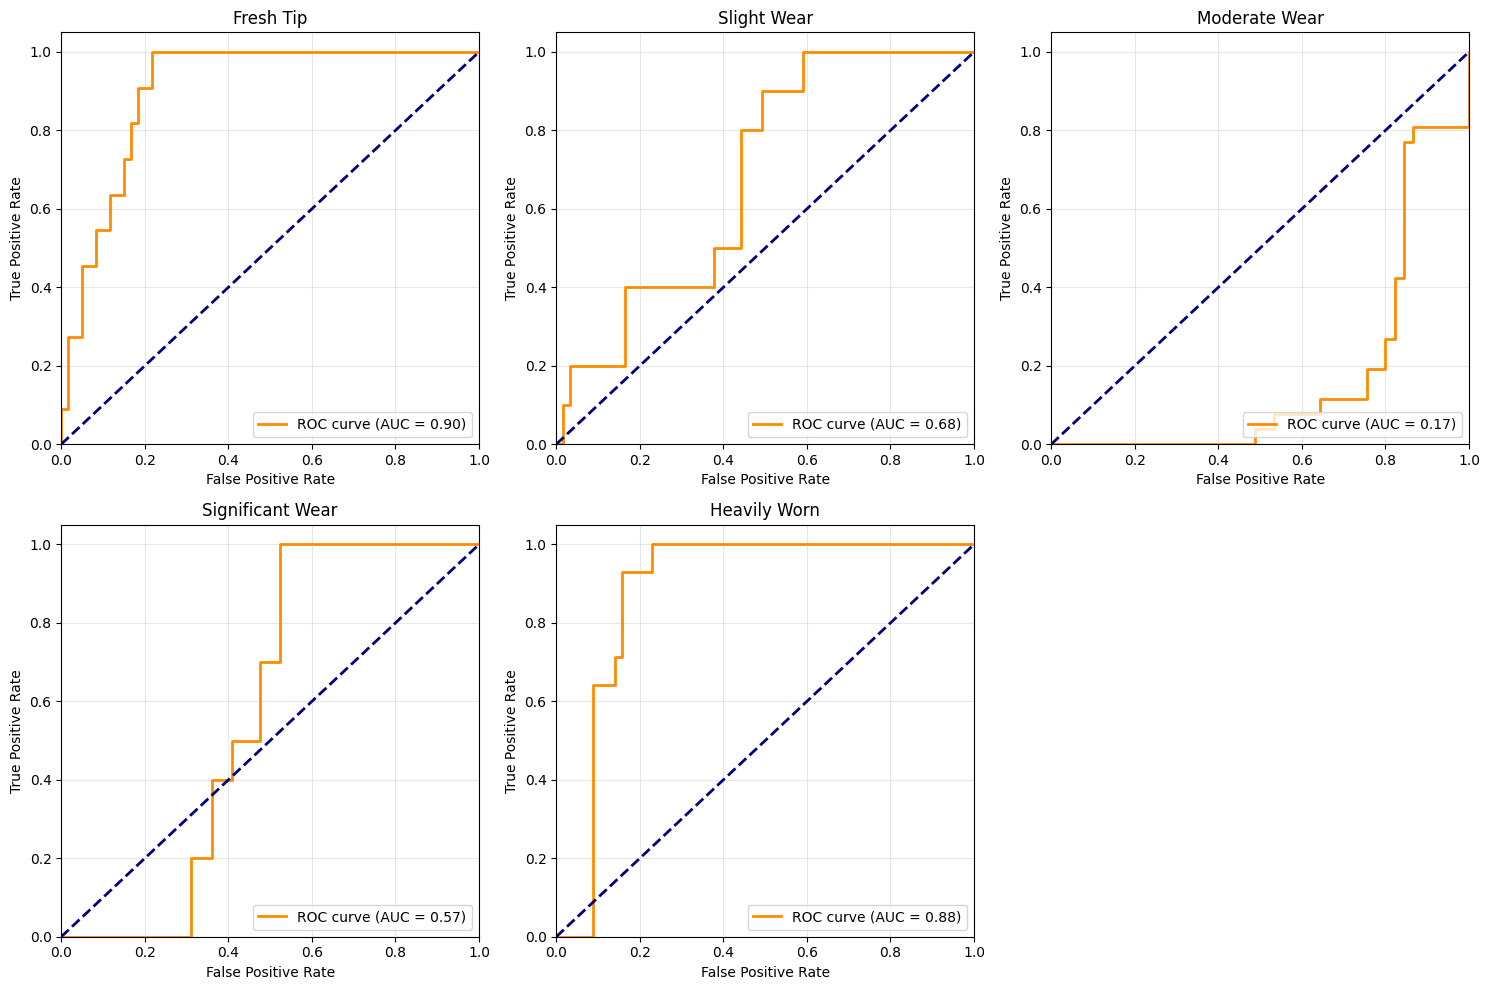

Generating confusion matrix...


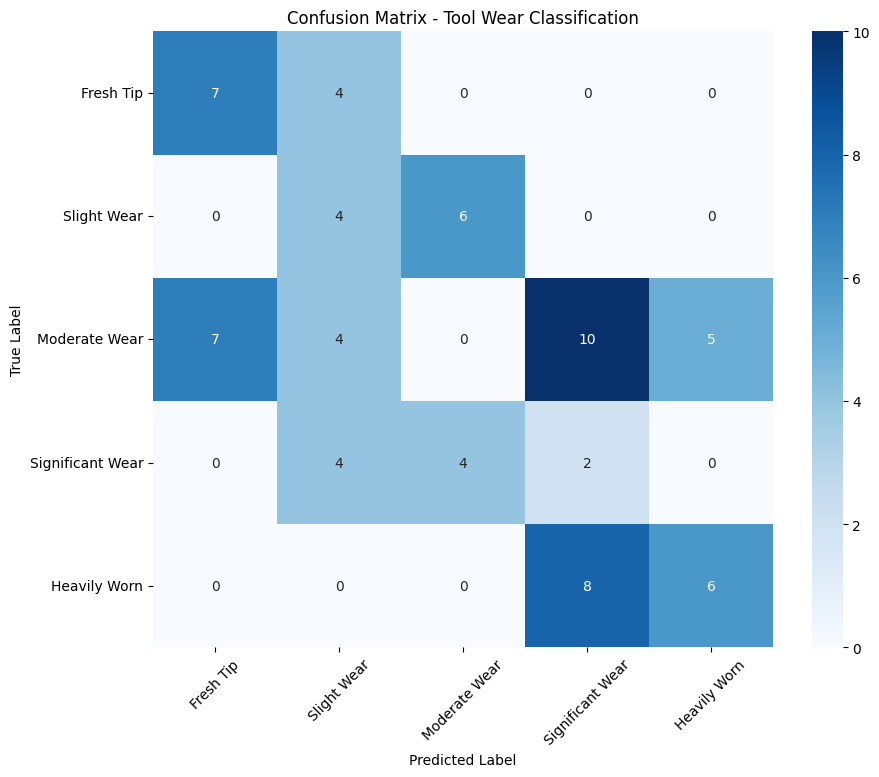


=== ROC ANALYSIS SUMMARY ===
              Class       AUC
0         Fresh Tip  0.904545
1       Slight Wear  0.683607
2     Moderate Wear  0.171795
3  Significant Wear  0.572131
4      Heavily Worn  0.883459

ROC analysis completed!


In [3]:
if __name__ == "__main__":
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') 
                                and torch.has_mps and torch.mps.is_available() else 'cpu')
    from tools import bt_run_complete_roc_analysis
    
    # Run complete ROC analysis
    roc_auc, summary, detailed_results = bt_run_complete_roc_analysis(
        model_path="barlow_twins_multiclass_classifier.pth",
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="roc_analysis",
        device=device,
        num_classes=5
    )
    
    print("\nROC analysis completed!")